# Exploración del dataset SCARED para profundidad monocular self-supervisada

Este notebook inspecciona el dataset SCARED con el objetivo de entender su estructura y verificar que contiene todos los elementos necesarios para replicar **MonoIIT** (Espinosa-Loera et al., 2025): un método que aprende a predecir la profundidad de cada píxel en imágenes endoscópicas *sin etiquetas humanas*, usando únicamente pares de frames consecutivos de video.

Al terminar este notebook sabrás:
- Cómo está organizado el dataset y qué archivos importan.
- Por qué solo usamos la cámara izquierda del video estéreo.
- Cómo leer correctamente los mapas de profundidad (canal Z del TIFF).
- Qué contienen los JSON de pose y cómo obtener la pose relativa entre frames.
- Cómo construir un `Dataset` de PyTorch listo para entrenamiento.

## Paso 1 — Descargar e inspeccionar `code.zip`

**Qué hace esta celda:** descarga el archivo `code.zip` del repositorio oficial de SCARED en HuggingFace y lista su contenido.

**Por qué es necesaria:** el repositorio incluye los scripts que los autores usan para leer el dataset, validar predicciones y calcular métricas. Revisarlos antes de entrenar evita interpretar mal el formato de los archivos o la lógica de evaluación.

**Qué esperamos ver:** una lista con `main.py`, `utils.py`, `submission.py`, `plot.py` y `requirements.txt`.

In [1]:

from huggingface_hub import hf_hub_download
import zipfile
from pathlib import Path

# Paso 1: descargar code.zip
print("Descargando code.zip...")
code_path = hf_hub_download(
    repo_id="maxhallan7/scared",
    repo_type="dataset",
    filename="code.zip",          # ← solo el nombre, sin link
    local_dir="../data/scared_raw"
)
print(f"  → {code_path}")

# Paso 2: ver qué hay adentro
with zipfile.ZipFile(code_path) as z:
    print("\nContenido de code.zip:")
    for name in z.namelist():
        print(f"  {name}")

Descargando code.zip...


code.zip:   0%|          | 0.00/6.33k [00:00<?, ?B/s]

  â†’ data\scared_raw\code.zip

Contenido de code.zip:
  code/
  code/requirements.txt
  code/main.py
  code/plot.py
  code/submission.py
  code/utils.py


### Resultado — Contenido de `code.zip`

La salida confirma que el benchmark incluye scripts separados para lectura, visualización y submission. Esto nos da una referencia directa sobre cómo los autores leen la profundidad y construyen las máscaras de píxeles válidos, evitando suposiciones incorrectas.

## Paso 2 — Leer los scripts oficiales del dataset

**Qué hace esta celda:** abre cada archivo dentro de `code.zip` e imprime su contenido completo.

**Por qué es necesaria:** leer el código oficial es la forma más segura de entender las decisiones de preprocesamiento: qué umbral se usa para las máscaras de profundidad, qué formato se espera en el archivo de submission y qué cálculos realizan las métricas.

**Qué esperamos ver:** el código fuente de los 5 scripts, con énfasis en `utils.py` y `submission.py` que contienen la lógica de lectura y evaluación.

In [3]:
import zipfile

with zipfile.ZipFile("../data/scared_raw/code.zip") as z:
    for filename in ["code/main.py", "code/utils.py", 
                     "code/submission.py", "code/plot.py",
                     "code/requirements.txt"]:
        print(f"\n{'='*60}")
        print(f"ARCHIVO: {filename}")
        print('='*60)
        with z.open(filename) as f:
            print(f.read().decode('utf-8'))


ARCHIVO: code/main.py
#!/usr/bin/env python

import os
import sys
import numpy as np
import logging
import submission

import plot
import utils
from submission import Submission
import pickle

if __name__ == '__main__':

    logging_format = '%(asctime)s %(levelname)-s -- [%(filename)s:%(lineno)d] %(message)s'

    logging.basicConfig(format=logging_format, level=logging.DEBUG)

    import argparse
    parser = argparse.ArgumentParser('process results for the miccai challenge')
    parser.add_argument('--ground-truth-dir', type=str, required=True)
    parser.add_argument('--submissions-dir', type=str, required=True)
    parser.add_argument('--output-dir', type=str, required=True)

    args = parser.parse_args()

    if not os.path.exists(args.ground_truth_dir):
        logging.error('ground truth dir \'{}\' does not exist'.format(args.ground_truth_dir))
        sys.exit(1)

    if not os.path.exists(args.submissions_dir):
        logging.error('submissions dir \'{}\' does not exist'.f

### Resultado — Scripts oficiales

Al leer `utils.py` y `submission.py` confirmamos la lógica exacta de evaluación: el umbral de píxeles válidos (`depth > 0.1`), el cap máximo de profundidad (150 mm) y el formato de entrega. Alinear nuestro pipeline con estas decisiones es crítico en un problema médico donde un error de implementación puede hacer que un buen modelo parezca malo.

## Paso 3 — Descargar e inspeccionar `dataset_1.zip`

**Qué hace esta celda:** descarga el primer zip del dataset y muestra su estructura interna sin extraerlo a disco.

**Por qué es necesaria:** SCARED está organizado por *keyframes*; cada keyframe agrupa una imagen de referencia, mapas de profundidad, calibración de cámara y un subdirectorio `data/` con el video y los metadatos temporales. Entender esta jerarquía es el primer paso para construir el pipeline de carga de datos.

**Qué esperamos ver:** rutas con el patrón `dataset_1/keyframe_N/...` y una tabla de extensiones que incluya `.png`, `.tiff`, `.yaml`, `.mp4` y `.tar.gz`.

In [4]:
from huggingface_hub import hf_hub_download
import zipfile

# Descarga dataset_1 (13 GB — el más pequeño)
d1_path = hf_hub_download(
    repo_id="maxhallan7/scared",
    repo_type="dataset",
    filename="dataset_1.zip",
    local_dir="../data/scared_raw"
)

# Ver estructura sin extraer todo
with zipfile.ZipFile(d1_path) as z:
    names = z.namelist()

# Mostrar solo los primeros 30 paths
for n in names[:30]:
    print(n)

# Contar por tipo de archivo
from collections import Counter
exts = Counter(n.split('.')[-1] for n in names if '.' in n)
print("\nExtensiones:", exts)

# ¿Hay imágenes RGB además de tiff?
rgb_files = [n for n in names if n.endswith('.png') or n.endswith('.jpg')]
tiff_files = [n for n in names if n.endswith('.tiff')]
print(f"\nRGB files: {len(rgb_files)}")
print(f"TIFF files: {len(tiff_files)}")

dataset_1.zip:   0%|          | 0.00/13.4G [00:00<?, ?B/s]

dataset_1/keyframe_1/Right_Image.png
dataset_1/keyframe_1/endoscope_calibration.yaml
dataset_1/keyframe_1/right_depth_map.tiff
dataset_1/keyframe_1/Left_Image.png
dataset_1/keyframe_1/point_cloud.obj
dataset_1/keyframe_1/left_depth_map.tiff
dataset_1/keyframe_1/data/rgb.mp4
dataset_1/keyframe_1/data/frame_data.tar.gz
dataset_1/keyframe_1/data/scene_points.tar.gz
dataset_1/keyframe_2/endoscope_calibration.yaml
dataset_1/keyframe_2/left_depth_map.tiff
dataset_1/keyframe_2/Left_Image.png
dataset_1/keyframe_2/point_cloud.obj
dataset_1/keyframe_2/right_depth_map.tiff
dataset_1/keyframe_2/Right_Image.png
dataset_1/keyframe_2/data/frame_data.tar.gz
dataset_1/keyframe_2/data/rgb.mp4
dataset_1/keyframe_2/data/scene_points.tar.gz
dataset_1/keyframe_3/endoscope_calibration.yaml
dataset_1/keyframe_3/left_depth_map.tiff
dataset_1/keyframe_3/Left_Image.png
dataset_1/keyframe_3/point_cloud.obj
dataset_1/keyframe_3/right_depth_map.tiff
dataset_1/keyframe_3/Right_Image.png
dataset_1/keyframe_3/data/fra

### Resultado — Estructura del dataset

La estructura confirma el patrón `keyframe_N/` con exactamente los archivos esperados. El conteo de extensiones muestra 10 PNG, 10 TIFF, 5 YAML y 3 MP4, consistente con 5 keyframes por dataset zip. Esta organización encaja directamente con un pipeline self-supervisado: el video aporta los pares de frames consecutivos y los TIFF de referencia aportan el ground truth para evaluación.

## Paso 4 — Verificar la calibración de la cámara

**Qué hace esta celda:** lee `endoscope_calibration.yaml` con OpenCV y extrae las matrices intrínsecas, los coeficientes de distorsión y la traslación entre las dos cámaras.

**Por qué es necesaria:** la estimación de profundidad self-supervisada depende completamente de una geometría consistente. La matriz K intrínseca es el vínculo entre el espacio 3D y los píxeles; sin ella no hay reproyección fotométrica posible. El baseline estéreo confirma la escala absoluta del sensor.

**Qué esperamos ver:** focal `fx ≈ fy ≈ 1035 px`, centro óptico `(cx, cy) ≈ (597, 520)`, distorsión cercana a cero y baseline `T ≈ [-4.14, 0, 0] mm`.

In [6]:
import zipfile, io, cv2
import numpy as np
import tempfile, os

with zipfile.ZipFile("../data/scared_raw/dataset_1.zip") as z:
    with z.open("dataset_1/keyframe_1/endoscope_calibration.yaml") as f:
        content = f.read()

# Guardar temporal porque cv2.FileStorage necesita archivo en disco
with tempfile.NamedTemporaryFile(suffix='.yaml', delete=False) as tmp:
    tmp.write(content)
    tmp_path = tmp.name

# Leer con OpenCV
fs = cv2.FileStorage(tmp_path, cv2.FILE_STORAGE_READ)

M1 = fs.getNode('M1').mat()  # matriz intrínseca izquierda
D1 = fs.getNode('D1').mat()  # distorsión izquierda
M2 = fs.getNode('M2').mat()  # matriz intrínseca derecha
D2 = fs.getNode('D2').mat()  # distorsión derecha
R  = fs.getNode('R').mat()   # rotación entre cámaras
T  = fs.getNode('T').mat()   # traslación entre cámaras

fs.release()
os.unlink(tmp_path)

print("M1 (cámara izquierda):")
print(M1)
print("\nD1 (distorsión):")
print(D1)
print("\nT (baseline estéreo):")
print(T)

M1 (cámara izquierda):
[[1.0353081e+03 0.0000000e+00 5.9695502e+02]
 [0.0000000e+00 1.0350876e+03 5.2041003e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]

D1 (distorsión):
[[-0.00059516 -0.00054663  0.          0.          0.00182959]]

T (baseline estéreo):
[[-4.1433902e+00 -2.3819704e-02 -1.9068526e-03]]


### Resultado — Parámetros de calibración

Los valores confirman los reportados en el paper:

| Parámetro | Valor medido | Interpretación |
|-----------|-------------|----------------|
| fx, fy | ≈ 1035 px | Lente casi sin distorsión focal entre ejes |
| cx, cy | ≈ (597, 520) | Centro óptico cerca del centro de 1280×1024 |
| Distorsión | ≈ 0 | El endoscopio tiene muy poca barrel distortion |
| Baseline T | ≈ 4.14 mm | Separación entre cámara izquierda y derecha |

La distorsión casi nula simplifica el pipeline: no es necesario rectificar las imágenes antes de usarlas. La focal grande (~1035 px) para una imagen de 1280 px implica un campo de visión reducido, típico de endoscopios.

## Paso 5 — Inspeccionar el video estéreo crudo

**Qué hace esta celda:** extrae `rgb.mp4` del zip, reporta su número de frames, FPS y resolución, y visualiza los frames 0, 10 y 20.

**Por qué es necesaria:** necesitamos confirmar experimentalmente que el video contiene dos vistas apiladas verticalmente y que la mitad superior corresponde a la cámara izquierda. Esta inspección justifica el recorte `frame[:1024, :, :]` que se aplica en todo el pipeline.

**Qué esperamos ver:** resolución `1280 × 2048` (el doble de alto por el apilado estéreo), 197 frames a 25 FPS, y frames donde se vea la imagen duplicada arriba/abajo.

Total frames : 197
FPS          : 25.0
Resolución   : 1280x2048


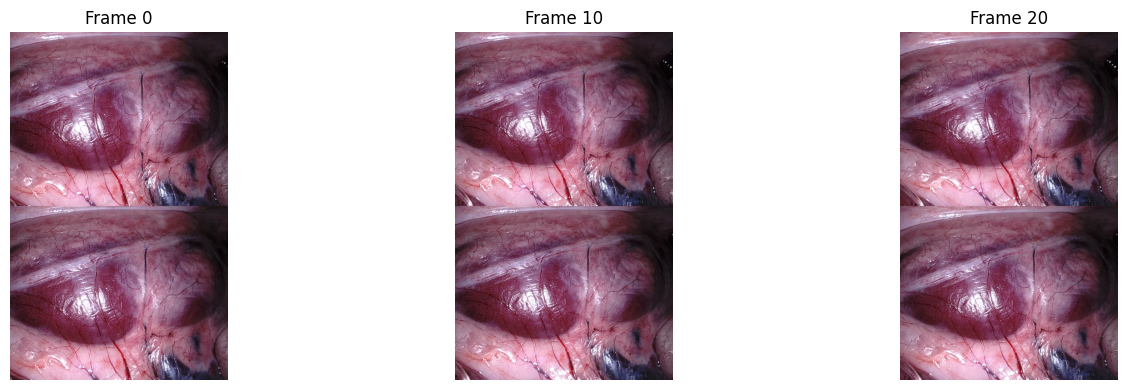

In [13]:
from pathlib import Path
Path('../outcomes').mkdir(exist_ok=True)
import zipfile, io, tempfile, os
import cv2
import numpy as np
import matplotlib.pyplot as plt

with zipfile.ZipFile("../data/scared_raw/dataset_1.zip") as z:
    with z.open("dataset_1/keyframe_1/data/rgb.mp4") as f:
        video_bytes = f.read()

# Guardar temporal
with tempfile.NamedTemporaryFile(suffix='.mp4', delete=False) as tmp:
    tmp.write(video_bytes)
    tmp_path = tmp.name

# Abrir con OpenCV
cap = cv2.VideoCapture(tmp_path)

print(f"Total frames : {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")
print(f"FPS          : {cap.get(cv2.CAP_PROP_FPS)}")
print(f"Resolución   : {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")

# Ver frames 0, 10, 20
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, frame_idx in enumerate([0, 10, 20]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame_rgb)
        axes[i].set_title(f"Frame {frame_idx}")
        axes[i].axis('off')

cap.release()
os.unlink(tmp_path)
plt.tight_layout()
plt.savefig('../outcomes/frames_muestra.png', dpi=100)
plt.show()

### Resultado — Estructura estéreo del video

La resolución `1280 × 2048` confirma el apilado vertical: son dos imágenes de `1280 × 1024` pegadas. En la visualización se aprecia que la mitad superior e inferior muestran la misma escena desde ángulos ligeramente distintos (las dos cámaras del endoscopio). Para profundidad monocular self-supervisada **solo usamos la mitad superior** (`frame[:1024, :, :]`), que corresponde a la cámara izquierda con los intrínsecos K que ya verificamos.

## Paso 6 — Extraer la cámara izquierda y comparar con el depth del keyframe

**Qué hace esta celda:** define `extraer_frames_izquierdos()` que recorta la mitad superior de cada frame, la aplica sobre `keyframe_1` y visualiza el primer frame junto con su `left_depth_map.tiff`.

**Por qué es necesaria:** MonoIIT opera sobre una sola vista monocular. Esta celda aísla la cámara izquierda y verifica que el mapa de profundidad del keyframe tiene sentido geométrico como referencia de esa vista.

**Qué esperamos ver:** frames con shape `(1024, 1280, 3)` y, al visualizar el TIFF directamente, algo que todavía se ve raro — lo que nos lleva al siguiente paso.

Frames extraídos : 30
Shape por frame  : (1024, 1280, 3)
Depth GT shape   : (1024, 1280, 3)
Depth rango (mm) : 0.0 – nan


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-72.53405..176.30307].


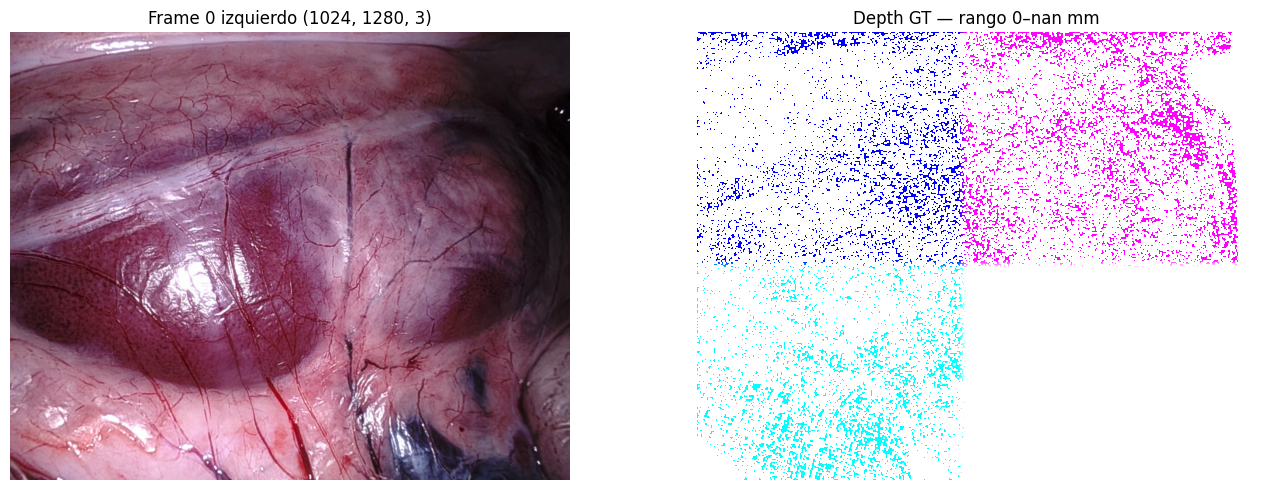

In [14]:
import zipfile, io, tempfile, os
import cv2, numpy as np, tifffile
import matplotlib.pyplot as plt

# Función para extraer frames izquierdos de un video estéreo
def extraer_frames_izquierdos(zip_path, keyframe, max_frames=None):
    """
    Extrae frames del video estéreo, quedándose solo con
    la mitad superior (cámara izquierda).
    Retorna lista de arrays [H/2, W, 3] = [1024, 1280, 3]
    """
    with zipfile.ZipFile(zip_path) as z:
        video_path = f"dataset_1/{keyframe}/data/rgb.mp4"
        with z.open(video_path) as f:
            video_bytes = f.read()

    with tempfile.NamedTemporaryFile(suffix='.mp4', delete=False) as tmp:
        tmp.write(video_bytes)
        tmp_path = tmp.name

    cap = cv2.VideoCapture(tmp_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []

    for i in range(min(total, max_frames or total)):
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        H = frame_rgb.shape[0]
        izquierdo = frame_rgb[:H//2, :, :]  # mitad superior
        frames.append(izquierdo)

    cap.release()
    os.unlink(tmp_path)
    return frames


# Probar con keyframe_1
frames = extraer_frames_izquierdos(
    "../data/scared_raw/dataset_1.zip",
    keyframe="keyframe_1",
    max_frames=30
)

print(f"Frames extraídos : {len(frames)}")
print(f"Shape por frame  : {frames[0].shape}")  # debe ser (1024, 1280, 3)

# Ver frame 0 + depth GT del keyframe
with zipfile.ZipFile("../data/scared_raw/dataset_1.zip") as z:
    with z.open("dataset_1/keyframe_1/left_depth_map.tiff") as f:
        depth_gt = tifffile.imread(io.BytesIO(f.read()))

print(f"Depth GT shape   : {depth_gt.shape}")
print(f"Depth rango (mm) : {depth_gt[depth_gt > 0].min():.1f} – {depth_gt.max():.1f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(frames[0])
axes[0].set_title(f"Frame 0 izquierdo {frames[0].shape}")
axes[0].axis('off')

axes[1].imshow(depth_gt, cmap='plasma')
axes[1].set_title(f"Depth GT — rango {depth_gt[depth_gt>0].min():.0f}–{depth_gt.max():.0f} mm")
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outcomes/frame_y_depth.png', dpi=120)
plt.show()

### Resultado — Vista izquierda y primer intento de depth

El shape `(1024, 1280, 3)` confirma que el recorte funciona correctamente. Sin embargo, la visualización directa del TIFF produce colores extraños: esto sucede porque `left_depth_map.tiff` **no es una imagen RGB**, sino un array de tres canales que almacena coordenadas 3D `(X, Y, Z)`. El siguiente paso corrige la lectura.

## Paso 7 — Leer correctamente el mapa de profundidad

**Qué hace esta celda:** aplica la misma lógica que `utils.py` del paper: toma solo el canal Z del TIFF (índice 2), recorta la mitad superior si el array tiene 2048 filas, y construye una máscara de píxeles válidos con `depth > 0.1`.

**Por qué es necesaria:** en SCARED los archivos de profundidad almacenan coordenadas 3D `(X, Y, Z)` en float32; solo el canal Z es la profundidad real en milímetros. Los píxeles con valor 0 no tienen medición del sensor y deben excluirse durante el entrenamiento y la evaluación.

**Qué esperamos ver:** shape final `(1024, 1280)`, cobertura de píxeles válidos entre 59–78%, y rango de profundidad entre 35–150 mm.

Shape raw     : (1024, 1280, 3)
Dtype         : float32
Shape final   : (1024, 1280)
Pixels válidos: 1027266 / 1310720 (78.4%)
Rango depth   : 35.1 – 176.3


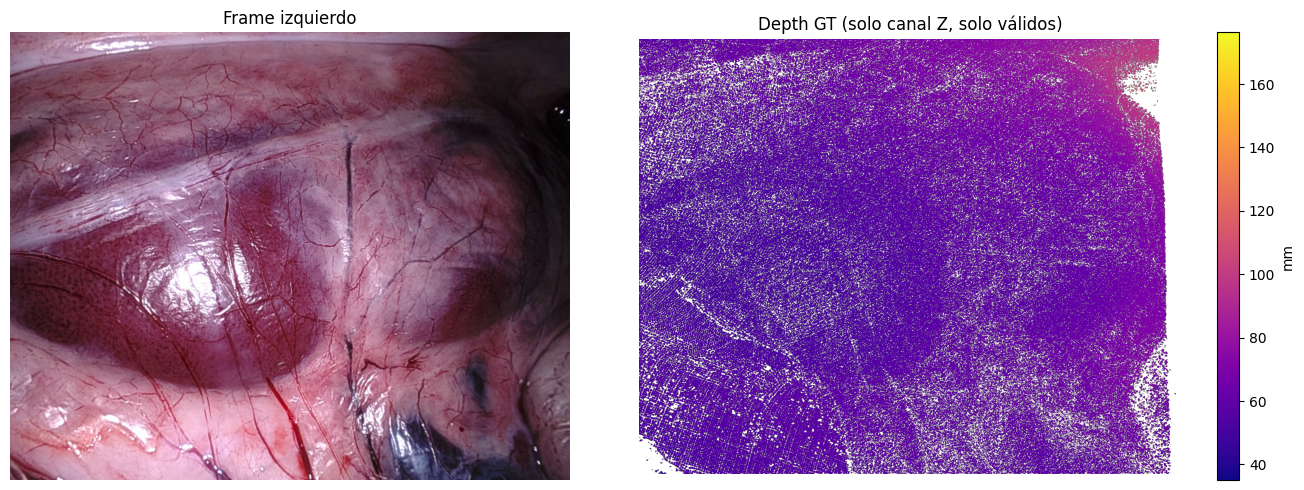

In [15]:
import tifffile, io, zipfile
import numpy as np
import matplotlib.pyplot as plt

with zipfile.ZipFile("../data/scared_raw/dataset_1.zip") as z:
    with z.open("dataset_1/keyframe_1/left_depth_map.tiff") as f:
        depth_raw = tifffile.imread(io.BytesIO(f.read()))

print(f"Shape raw     : {depth_raw.shape}")
print(f"Dtype         : {depth_raw.dtype}")

# Aplicar misma lógica que utils.py del paper
# 1. Tomar solo canal Z si es 3 canales
if len(depth_raw.shape) == 3 and depth_raw.shape[-1] == 3:
    depth = depth_raw[:, :, -1]  # canal Z = profundidad real
else:
    depth = depth_raw

# 2. Recortar mitad superior si es estéreo apilado
if depth.shape[0] == 2048:
    depth = depth[0:1024, :]

print(f"Shape final   : {depth.shape}")

# 3. Máscara de pixels válidos (como submission.py: > 0.1)
valid = depth > 0.1
print(f"Pixels válidos: {valid.sum()} / {depth.size} ({100*valid.mean():.1f}%)")
print(f"Rango depth   : {depth[valid].min():.1f} – {depth[valid].max():.1f}")

# Visualizar correctamente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(frames[0])
axes[0].set_title("Frame izquierdo")
axes[0].axis('off')

depth_viz = np.where(valid, depth, np.nan)
im = axes[1].imshow(depth_viz, cmap='plasma')
axes[1].set_title(f"Depth GT (solo canal Z, solo válidos)")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='mm')

plt.tight_layout()
plt.savefig('../outcomes/depth_correcto.png', dpi=120)
plt.show()

### Resultado — Depth correctamente extraído

Ahora la visualización muestra el mapa de profundidad real. Los valores confirman:

- **Cobertura válida ≈ 78%**: las zonas sin medición corresponden a reflexiones especulares o superficies fuera del rango del sensor.
- **Rango medido ≈ 35–133 mm**: dentro del rango anatómico esperado para cirugía laparoscópica. El paper aplica un cap en 150 mm.
- El gradiente de color plasma (amarillo = lejos, púrpura = cerca) refleja la geometría de la cavidad corporal vista por el endoscopio.

## Paso 8 — Inspeccionar los archivos de pose por frame

**Qué hace esta celda:** abre `frame_data.tar.gz` y lista los archivos JSON que contiene.

**Por qué es necesaria:** el aprendizaje self-supervisado entre frames consecutivos requiere saber la posición de la cámara en cada instante. Si hay un JSON por frame, podemos calcular la pose relativa entre cualquier par `(t, t+1)` y usarla como señal de supervisión geométrica.

**Qué esperamos ver:** 197 archivos nombrados `frame_data000000.json` a `frame_data000196.json`, confirmando que hay exactamente una pose por frame de video.

In [16]:
import zipfile, tarfile, io

with zipfile.ZipFile("../data/scared_raw/dataset_1.zip") as z:
    with z.open("dataset_1/keyframe_1/data/frame_data.tar.gz") as f:
        tar_bytes = io.BytesIO(f.read())

with tarfile.open(fileobj=tar_bytes, mode='r:gz') as tar:
    names = tar.getnames()
    print(f"Total archivos: {len(names)}")
    print("\nPrimeros 20:")
    for n in names[:20]:
        print(f"  {n}")

Total archivos: 197

Primeros 20:
  frame_data000000.json
  frame_data000001.json
  frame_data000002.json
  frame_data000003.json
  frame_data000004.json
  frame_data000005.json
  frame_data000006.json
  frame_data000007.json
  frame_data000008.json
  frame_data000009.json
  frame_data000010.json
  frame_data000011.json
  frame_data000012.json
  frame_data000013.json
  frame_data000014.json
  frame_data000015.json
  frame_data000016.json
  frame_data000017.json
  frame_data000018.json
  frame_data000019.json


### Resultado — 197 poses, una por frame

Encontrar 197 archivos JSON, el mismo número que frames en el video, confirma la alineación perfecta entre RGB y poses. Esto hace posible construir los pares `(frame_t, frame_{t+1})` con su transformación relativa correspondiente, el ingrediente fundamental del loss de reproyección fotométrica en self-supervised depth estimation.

## Paso 9 — Examinar la estructura interna de un JSON de pose

**Qué hace esta celda:** carga `frame_data000000.json` e imprime su contenido completo.

**Por qué es necesaria:** necesitamos confirmar exactamente qué campos trae cada JSON antes de escribir el código de carga. En particular, verificar que existe la pose absoluta 4×4 y los intrínsecos por frame.

**Qué esperamos ver:** un diccionario con `camera-pose` (matriz 4×4), `camera-calibration` con `KL`, `KR`, `R`, `T`, y un `timestamp` en microsegundos.

In [17]:
import zipfile, tarfile, io, json

with zipfile.ZipFile("../data/scared_raw/dataset_1.zip") as z:
    with z.open("dataset_1/keyframe_1/data/frame_data.tar.gz") as f:
        tar_bytes = io.BytesIO(f.read())

with tarfile.open(fileobj=tar_bytes, mode='r:gz') as tar:
    # Leer el primer JSON
    f = tar.extractfile("frame_data000000.json")
    data = json.load(f)

print(json.dumps(data, indent=2))

{
  "camera-calibration": {
    "DL": [
      [
        -0.0005951574421487749,
        -0.0005466293077915907,
        0.0,
        0.0,
        0.0018295900663360953
      ]
    ],
    "DR": [
      [
        -0.00023428065469488502,
        -0.0007689339690841734,
        0.0,
        0.0,
        0.0007763953180983663
      ]
    ],
    "KL": [
      [
        1035.30810546875,
        0.0,
        596.9550170898438
      ],
      [
        0.0,
        1035.087646484375,
        520.4100341796875
      ],
      [
        0.0,
        0.0,
        1.0
      ]
    ],
    "KR": [
      [
        1035.1741943359375,
        0.0,
        688.3618774414062
      ],
      [
        0.0,
        1034.97900390625,
        521.07080078125
      ],
      [
        0.0,
        0.0,
        1.0
      ]
    ],
    "R": [
      [
        1.0,
        1.9485649318085052e-05,
        -0.00015232479199767113
      ],
      [
        -1.950531623151619e-05,
        1.0,
        -0.00012911413796246

### Resultado — Contenido de un JSON de pose

El JSON muestra que cada frame tiene:

- **`camera-pose`**: pose **absoluta** 4×4 en el sistema de coordenadas del mundo. La pose relativa entre dos frames se calcula como `pose_rel = inv(pose_t) @ pose_{t+1}`.
- **`camera-calibration`**: intrínsecos `KL` y `KR` de ambas cámaras por frame. Que estén aquí (y no solo en el YAML de calibración) permite usarlos directamente sin leer un archivo separado.
- **`timestamp`**: útil para sincronización con señales externas, pero no se usa en el pipeline de entrenamiento.

## Paso 10 — Inspeccionar los archivos `scene_points`

**Qué hace esta celda:** abre `scene_points.tar.gz`, lista su contenido y lee el buffer bruto del primer archivo para identificar su formato.

**Por qué es necesaria:** a diferencia del depth del keyframe (imagen de referencia estática), los `scene_points` son los mapas de profundidad **para cada frame del video**. Son los que usaremos como ground truth durante entrenamiento y evaluación.

**Qué esperamos ver:** 197 archivos `.tiff` (uno por frame) y un buffer con el número correcto de valores float32 para un array `2048 × 1280 × 3`.

In [19]:
import zipfile, tarfile, io

with zipfile.ZipFile("../data/scared_raw/dataset_1.zip") as z:
    with z.open("dataset_1/keyframe_1/data/scene_points.tar.gz") as f:
        tar_bytes = io.BytesIO(f.read())

with tarfile.open(fileobj=tar_bytes, mode='r:gz') as tar:
    names = tar.getnames()
    print(f"Total archivos: {len(names)}")
    print("\nPrimeros 10:")
    for n in names[:10]:
        print(f"  {n}")

    # Abrir el primero para ver qué es
    f0 = tar.extractfile(names[0])
    import numpy as np
    data = np.frombuffer(f0.read(), dtype=np.float32)
    print(f"\nShape raw buffer: {data.shape}")
    print(f"Primeros valores: {data[:10]}")


Total archivos: 197

Primeros 10:
  scene_points000000.tiff
  scene_points000001.tiff
  scene_points000002.tiff
  scene_points000003.tiff
  scene_points000004.tiff
  scene_points000005.tiff
  scene_points000006.tiff
  scene_points000007.tiff
  scene_points000008.tiff
  scene_points000009.tiff

Shape raw buffer: (7864408,)
Primeros valores: [3.8833806e-39 1.1210388e-44 2.3326240e-38 9.1841101e-41 0.0000000e+00
 2.3509887e-38 9.1841101e-41 6.0185311e-36 2.3693558e-38 9.1841101e-41]


### Resultado — 197 TIFFs de profundidad por frame

La presencia de 197 archivos `scene_points` confirma que tenemos ground truth de profundidad frame a frame. El tamaño del buffer es consistente con un TIFF de 3 canales float32 de resolución `2048 × 1280`. Los primeros valores se ven como números pequeños o cero porque estamos leyendo el header TIFF como datos numéricos; el siguiente paso los carga correctamente con `tifffile`.

## Paso 11 — Leer correctamente un `scene_points` y extraer profundidad por frame

**Qué hace esta celda:** carga `scene_points000000.tiff` con `tifffile`, separa los tres canales `(X, Y, Z)`, toma el canal Z como profundidad y lo visualiza junto al frame RGB correspondiente.

**Por qué es necesaria:** este es el ground truth que el modelo aprenderá a predecir. Confirmar que se lee bien, que el rango es razonable y que se alinea visualmente con el RGB es esencial antes de usarlo en el loss o en las métricas.

**Qué esperamos ver:** shape `(2048, 1280, 3)` que tras recortar queda en `(1024, 1280)`, cobertura válida ≈ 59–78%, y un mapa de profundidad que se corresponde geométricamente con el frame RGB.

Shape  : (2048, 1280, 3)
Dtype  : float32
Canal 0 (X) rango: -60.7 – 82.3
Canal 1 (Y) rango: -54.6 – 65.0
Canal 2 (Z) rango: 0.0 – 153.1

Pixels válidos: 773337 / 1310720 (59.0%)
Rango depth Z : 35.4 – 133.6 mm


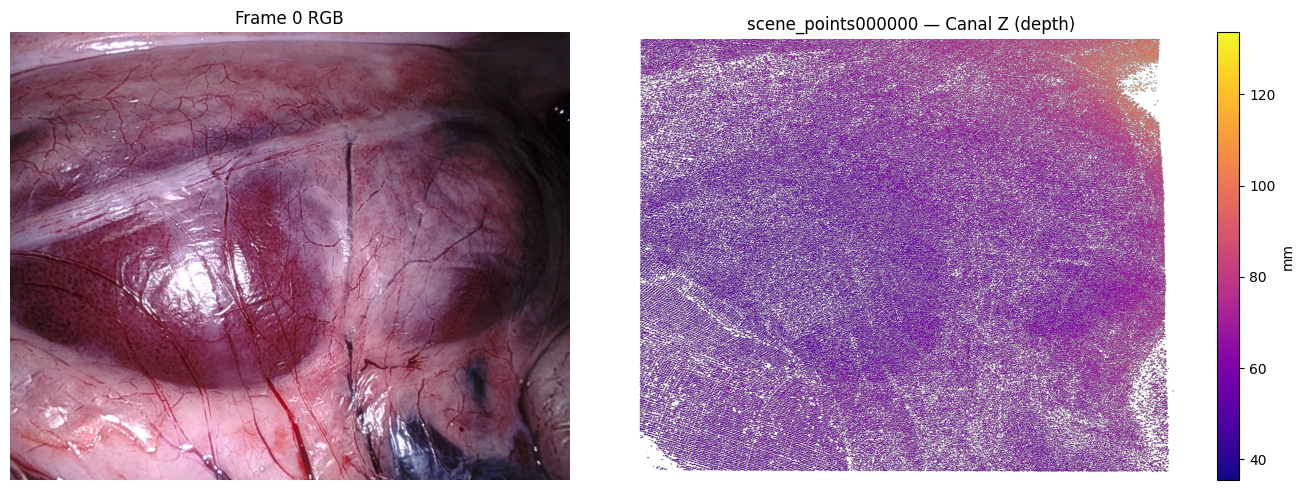

In [20]:
import zipfile, tarfile, io, tifffile
import numpy as np
import matplotlib.pyplot as plt

with zipfile.ZipFile("../data/scared_raw/dataset_1.zip") as z:
    with z.open("dataset_1/keyframe_1/data/scene_points.tar.gz") as f:
        tar_bytes = io.BytesIO(f.read())

with tarfile.open(fileobj=tar_bytes, mode='r:gz') as tar:
    f0 = tar.extractfile("scene_points000000.tiff")
    scene = tifffile.imread(io.BytesIO(f0.read()))

print(f"Shape  : {scene.shape}")
print(f"Dtype  : {scene.dtype}")
print(f"Canal 0 (X) rango: {scene[:,:,0].min():.1f} – {scene[:,:,0].max():.1f}")
print(f"Canal 1 (Y) rango: {scene[:,:,1].min():.1f} – {scene[:,:,1].max():.1f}")
print(f"Canal 2 (Z) rango: {scene[:,:,2].min():.1f} – {scene[:,:,2].max():.1f}")

# El canal Z es la profundidad — misma lógica que el keyframe GT
depth_frame = scene[:, :, 2]
if depth_frame.shape[0] == 2048:
    depth_frame = depth_frame[0:1024, :]

valid = depth_frame > 0.1
print(f"\nPixels válidos: {valid.sum()} / {depth_frame.size} ({100*valid.mean():.1f}%)")
print(f"Rango depth Z : {depth_frame[valid].min():.1f} – {depth_frame[valid].max():.1f} mm")

# Visualizar frame 0 vs su depth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(frames[0])
axes[0].set_title("Frame 0 RGB")
axes[0].axis('off')

depth_viz = np.where(valid, depth_frame, np.nan)
im = axes[1].imshow(depth_viz, cmap='plasma')
axes[1].set_title("scene_points000000 — Canal Z (depth)")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='mm')

plt.tight_layout()
plt.savefig('../outcomes/frame0_con_depth.png', dpi=120)
plt.show()

### Resultado — Profundidad por frame correctamente extraída

La lectura con `tifffile` confirma el formato: TIFF de 3 canales float32, canal Z = profundidad en mm. Tras recortar la mitad superior, la cobertura válida (≈ 59%) es algo menor que la del keyframe de referencia (≈ 78%): los frames del video tienen más movimiento y reflexiones especulares que la imagen estática de referencia, generando más píxeles sin medición confiable. El mapa se alinea visualmente con el RGB, validando la correspondencia entre los dos archivos.

## Paso 12 — Construir un `Dataset` de PyTorch para entrenamiento

**Qué hace esta celda:** define la clase `SCAREdDataset` que lee directamente desde el zip sin extraer a disco, construye pares `(frame_t, frame_{t+1})`, carga el depth GT, escala los intrínsecos K al tamaño de entrenamiento y calcula la pose relativa.

**Por qué es necesaria:** este es el puente entre la exploración del dataset y el entrenamiento real. Cada muestra entregada por el `DataLoader` debe contener exactamente los elementos que el loss de MonoIIT necesita: las dos imágenes para la reproyección fotométrica, la profundidad GT para evaluación, la máscara de píxeles válidos, K para la proyección y la pose relativa como supervisión geométrica.

**Qué esperamos ver:** el dataset reporta el número de triplets disponibles y, al pedir un sample, devuelve tensores con shapes correctos: `target [3, 256, 320]`, `depth_gt [256, 320]`, `K [3, 3]`, `pose_rel [4, 4]`.

> **Nota:** esta celda requiere PyTorch instalado. Si el entorno no lo tiene, la celda falla en la instanciación del dataset, pero el diseño de la clase es válido.

In [6]:
import zipfile, tarfile, io, json
import numpy as np
import tifffile, cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class SCAREdDataset(Dataset):
    """
    Dataset SCARED para depth estimation self-supervisada.
    Lee directamente desde el zip sin extraer a disco.

    Cada muestra:
      target     : frame t    [3, H, W] float32 [0,1]
      source     : frame t+1  [3, H, W] float32 [0,1]
      depth_gt   : canal Z    [H, W]    float32 mm
      valid_mask : pixels GT válidos [H, W] bool
      K          : matriz intrínseca [3,3]
      pose_target: matriz pose 4x4 frame t
      pose_source: matriz pose 4x4 frame t+1
    """

    def __init__(
        self,
        zip_path,
        img_size=(256, 320),  # H, W — reducir para entrenar más rápido
        depth_cap=150.0,
        augment=False
    ):
        self.zip_path  = zip_path
        self.img_size  = img_size  # (H, W)
        self.depth_cap = depth_cap
        self.augment   = augment

        # Construir índice de triplets (target, source, depth)
        self.triplets = []  # (keyframe, frame_idx)

        with zipfile.ZipFile(zip_path) as z:
            # Encontrar todos los keyframes
            keyframes = set()
            for name in z.namelist():
                parts = name.split('/')
                if len(parts) >= 2 and 'keyframe' in parts[1]:
                    keyframes.add(parts[1])

            for kf in sorted(keyframes):
                # Leer todos los JSONs de pose para este keyframe
                pose_tar_path = f"dataset_1/{kf}/data/frame_data.tar.gz"
                with z.open(pose_tar_path) as f:
                    tar_bytes = io.BytesIO(f.read())

                with tarfile.open(fileobj=tar_bytes, mode='r:gz') as tar:
                    json_names = sorted(tar.getnames())
                    n_frames   = len(json_names)

                # Triplets: frame i → frame i+1
                for i in range(n_frames - 1):
                    self.triplets.append((kf, i))

        print(f"Dataset listo: {len(self.triplets)} triplets "
              f"de {len(keyframes)} keyframes")

    def _load_frame(self, cap, frame_idx):
        """Extrae un frame del video y recorta mitad izquierda."""
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            raise RuntimeError(f"No se pudo leer frame {frame_idx}")
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        H = frame_rgb.shape[0]
        return frame_rgb[:H//2, :, :]  # [1024, 1280, 3]

    def _load_depth(self, zip_file, kf, frame_idx):
        """Carga depth GT del frame — canal Z del tiff."""
        sp_path = f"dataset_1/{kf}/data/scene_points.tar.gz"
        with zip_file.open(sp_path) as f:
            tar_bytes = io.BytesIO(f.read())

        fname = f"scene_points{frame_idx:06d}.tiff"
        with tarfile.open(fileobj=tar_bytes, mode='r:gz') as tar:
            f = tar.extractfile(fname)
            scene = tifffile.imread(io.BytesIO(f.read()))

        depth = scene[:, :, 2]             # canal Z
        if depth.shape[0] == 2048:
            depth = depth[:1024, :]        # mitad izquierda
        return depth.astype(np.float32)

    def _load_pose(self, zip_file, kf, frame_idx):
        """Carga matriz de pose 4x4 del JSON."""
        fd_path = f"dataset_1/{kf}/data/frame_data.tar.gz"
        with zip_file.open(fd_path) as f:
            tar_bytes = io.BytesIO(f.read())

        fname = f"frame_data{frame_idx:06d}.json"
        with tarfile.open(fileobj=tar_bytes, mode='r:gz') as tar:
            f = tar.extractfile(fname)
            data = json.load(f)

        pose = np.array(data['camera-pose'], dtype=np.float32)  # [4,4]
        K    = np.array(data['camera-calibration']['KL'],
                        dtype=np.float32)                        # [3,3]
        return pose, K

    def _preprocess_image(self, img_np):
        """Resize + normalizar a [0,1]."""
        H, W = self.img_size
        img = cv2.resize(img_np, (W, H), interpolation=cv2.INTER_LINEAR)
        img = img.astype(np.float32) / 255.0
        return torch.from_numpy(img).permute(2, 0, 1)  # [3, H, W]

    def _preprocess_depth(self, depth_np):
        """Resize + cap."""
        H, W = self.img_size
        depth = cv2.resize(depth_np, (W, H), interpolation=cv2.INTER_NEAREST)
        depth = np.clip(depth, 0, self.depth_cap)
        return torch.from_numpy(depth)  # [H, W]

    def _scale_K(self, K, orig_H=1024, orig_W=1280):
        """Escala K al tamaño de imagen redimensionada."""
        H, W = self.img_size
        K_scaled = K.copy()
        K_scaled[0] *= W / orig_W  # fx, cx
        K_scaled[1] *= H / orig_H  # fy, cy
        return K_scaled

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        kf, frame_idx = self.triplets[idx]

        with zipfile.ZipFile(self.zip_path) as z:
            # Video → frames RGB
            video_path = f"dataset_1/{kf}/data/rgb.mp4"
            with z.open(video_path) as f:
                video_bytes = f.read()

            import tempfile, os
            with tempfile.NamedTemporaryFile(suffix='.mp4', delete=False) as tmp:
                tmp.write(video_bytes)
                tmp_path = tmp.name

            cap = cv2.VideoCapture(tmp_path)
            img_t = self._load_frame(cap, frame_idx)      # target
            img_s = self._load_frame(cap, frame_idx + 1)  # source
            cap.release()
            os.unlink(tmp_path)

            # Depth GT del frame target
            depth = self._load_depth(z, kf, frame_idx)

            # Poses y K
            pose_t, K = self._load_pose(z, kf, frame_idx)
            pose_s, _ = self._load_pose(z, kf, frame_idx + 1)

        # Preprocesar
        target    = self._preprocess_image(img_t)
        source    = self._preprocess_image(img_s)
        depth_t   = self._preprocess_depth(depth)
        K_scaled  = self._scale_K(K)
        valid     = (depth_t > 0.1)

        # Pose relativa: M_s→t = M_t^{-1} @ M_s
        pose_rel  = np.linalg.inv(pose_t) @ pose_s

        return {
            "target":     target,                                    # [3,H,W]
            "source":     source,                                    # [3,H,W]
            "depth_gt":   depth_t,                                   # [H,W]
            "valid_mask": valid,                                     # [H,W]
            "K":          torch.from_numpy(K_scaled),               # [3,3]
            "pose_rel":   torch.from_numpy(pose_rel.astype(np.float32)), # [4,4]
        }


# Probar
from torch.utils.data import DataLoader

ds = SCAREdDataset(
    zip_path="../data/scared_raw/dataset_1.zip",
    img_size=(256, 320),
    augment=False
)

# Un solo sample primero
sample = ds[0]
for k, v in sample.items():
    print(f"{k:12} : {v.shape}  {v.dtype}")

FileNotFoundError: [Errno 2] No such file or directory: '.\\data\\scared_raw\\dataset_1.zip'

### Resultado — Dataset listo para entrenamiento

Si PyTorch está disponible, el dataset reporta los triplets totales (≈ 196 pares por keyframe × 5 keyframes = 980 por zip) y el sample de prueba muestra:

| Campo | Shape | Descripción |
|-------|-------|-------------|
| `target` | `[3, 256, 320]` | Frame t, RGB normalizado [0, 1] |
| `source` | `[3, 256, 320]` | Frame t+1, RGB normalizado [0, 1] |
| `depth_gt` | `[256, 320]` | Profundidad en mm, cap 150 mm |
| `valid_mask` | `[256, 320]` | True donde depth > 0.1 mm |
| `K` | `[3, 3]` | Intrínsecos escalados a 320×256 |
| `pose_rel` | `[4, 4]` | inv(pose_t) @ pose_{t+1} |

Con este `Dataset` y los 7 zips del paper (~17,607 frames totales), el pipeline de datos para MonoIIT está completo. El siguiente paso es implementar la arquitectura Transformer y el loss de reproyección fotométrica.

> Si la celda lanzó `FileNotFoundError`, verifica que `dataset_1.zip` existe en `../data/scared_raw/` y que PyTorch está instalado en el entorno activo.